# **📊 EXPLORATORY DATA ANALYTICS**


---
### **1. IMPORTING MODULES**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### **2. LOADING TRAIN DATASET**

In [3]:
# read CSV to dataframe for train dataset
train_df = pd.read_csv(r"..\Processed Datasets\final_train.csv")

# Random 5 rows for the the starting of train dataset
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,26.0,2.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,62.0,3.0,1.0,0.0


---
### **3. TRAIN DATASET INFORMATION**

In [4]:
# Essential Details of the train dataset
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 239 entries, SK_ID_CURR to pos_demand_contracts
dtypes: float64(182), int64(41), str(16)
memory usage: 599.7 MB


---
### **4. LOADING TEST DATASET**

In [5]:
# read CSV to dataframe for test dataset
test_df = pd.read_csv(r"..\Processed Datasets\final_test.csv")

# Random 5 rows for the the starting of test dataset
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_payment_count,pos_serious_dpd_count,pos_active_contracts,pos_completed_contracts,pos_signed_contracts,pos_demand_contracts
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,26.0,2.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,62.0,3.0,1.0,0.0


---
### **5. TEST DATASET INFORMATION**

In [6]:
# Essential Details of the testdataset
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 238 entries, SK_ID_CURR to pos_demand_contracts
dtypes: float64(182), int64(40), str(16)
memory usage: 94.7 MB


### **6. PLOTTING MISSING VALUES IN BAR GRAPH**

In [33]:
# Made a custom function to plot the missing value percentage for train/test datasets
def Missing_value_plotter(dataset, xlabel, ylabel, title):    

    # Storing missing value count of all features
    missing = dataset.isna().sum().sort_values(ascending=False)
    # Storing features having missing value count > 0
    missing = missing[missing > 0]
    # storing the missing value percentage of all features
    missing_pct = (
        dataset.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    # Storing the missing value percentage of the features stored in 'missing'
    missing_pct = missing_pct[missing.index]
    # fig size of 17, length of missing values and 0.2 is for some extra space
    plt.figure(figsize=(17, max(5, len(missing) * 0.2)))
    plt.margins(y=0.001)

    bars = plt.barh(missing.index, missing.values, color=["#5ACCB3", "#6EB5D6", "#D44E4E", "#A8E76D", "#905EBE"])

    for bar, pct in zip(bars, missing_pct):
        plt.text(
            bar.get_width() + missing.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{pct:.2f}%",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize = 16, fontweight = 'bold')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

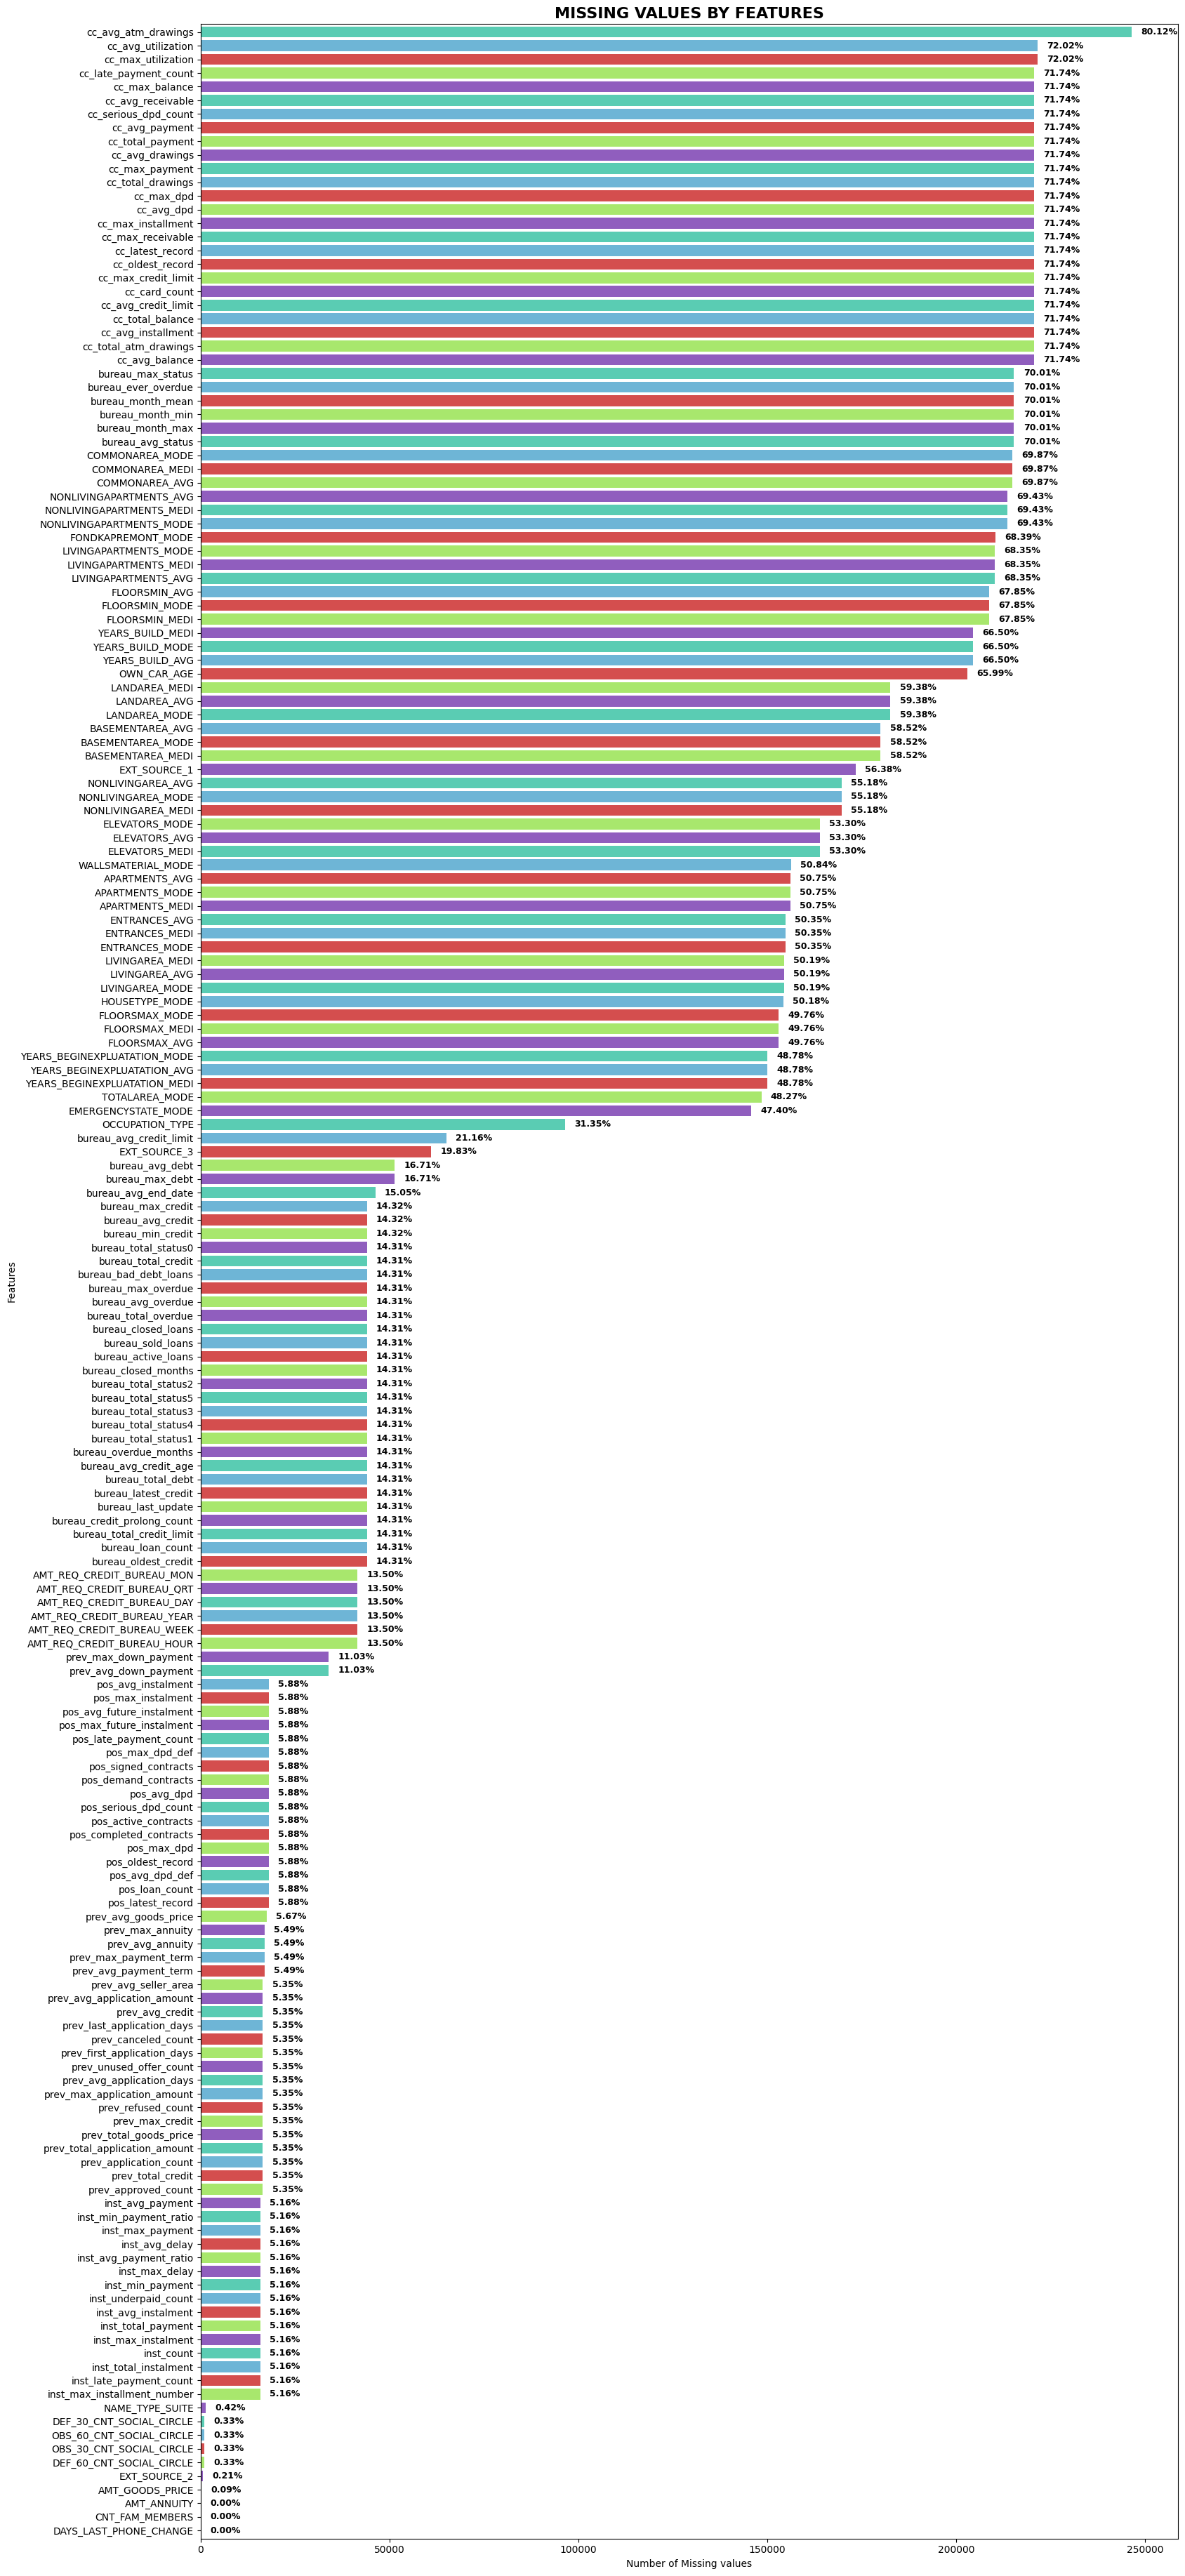

In [34]:
# Missing values in train dataset
Missing_value_plotter(
        train_df, 
        "Number of Missing values", 
        "Features",
        "MISSING VALUES BY FEATURES")

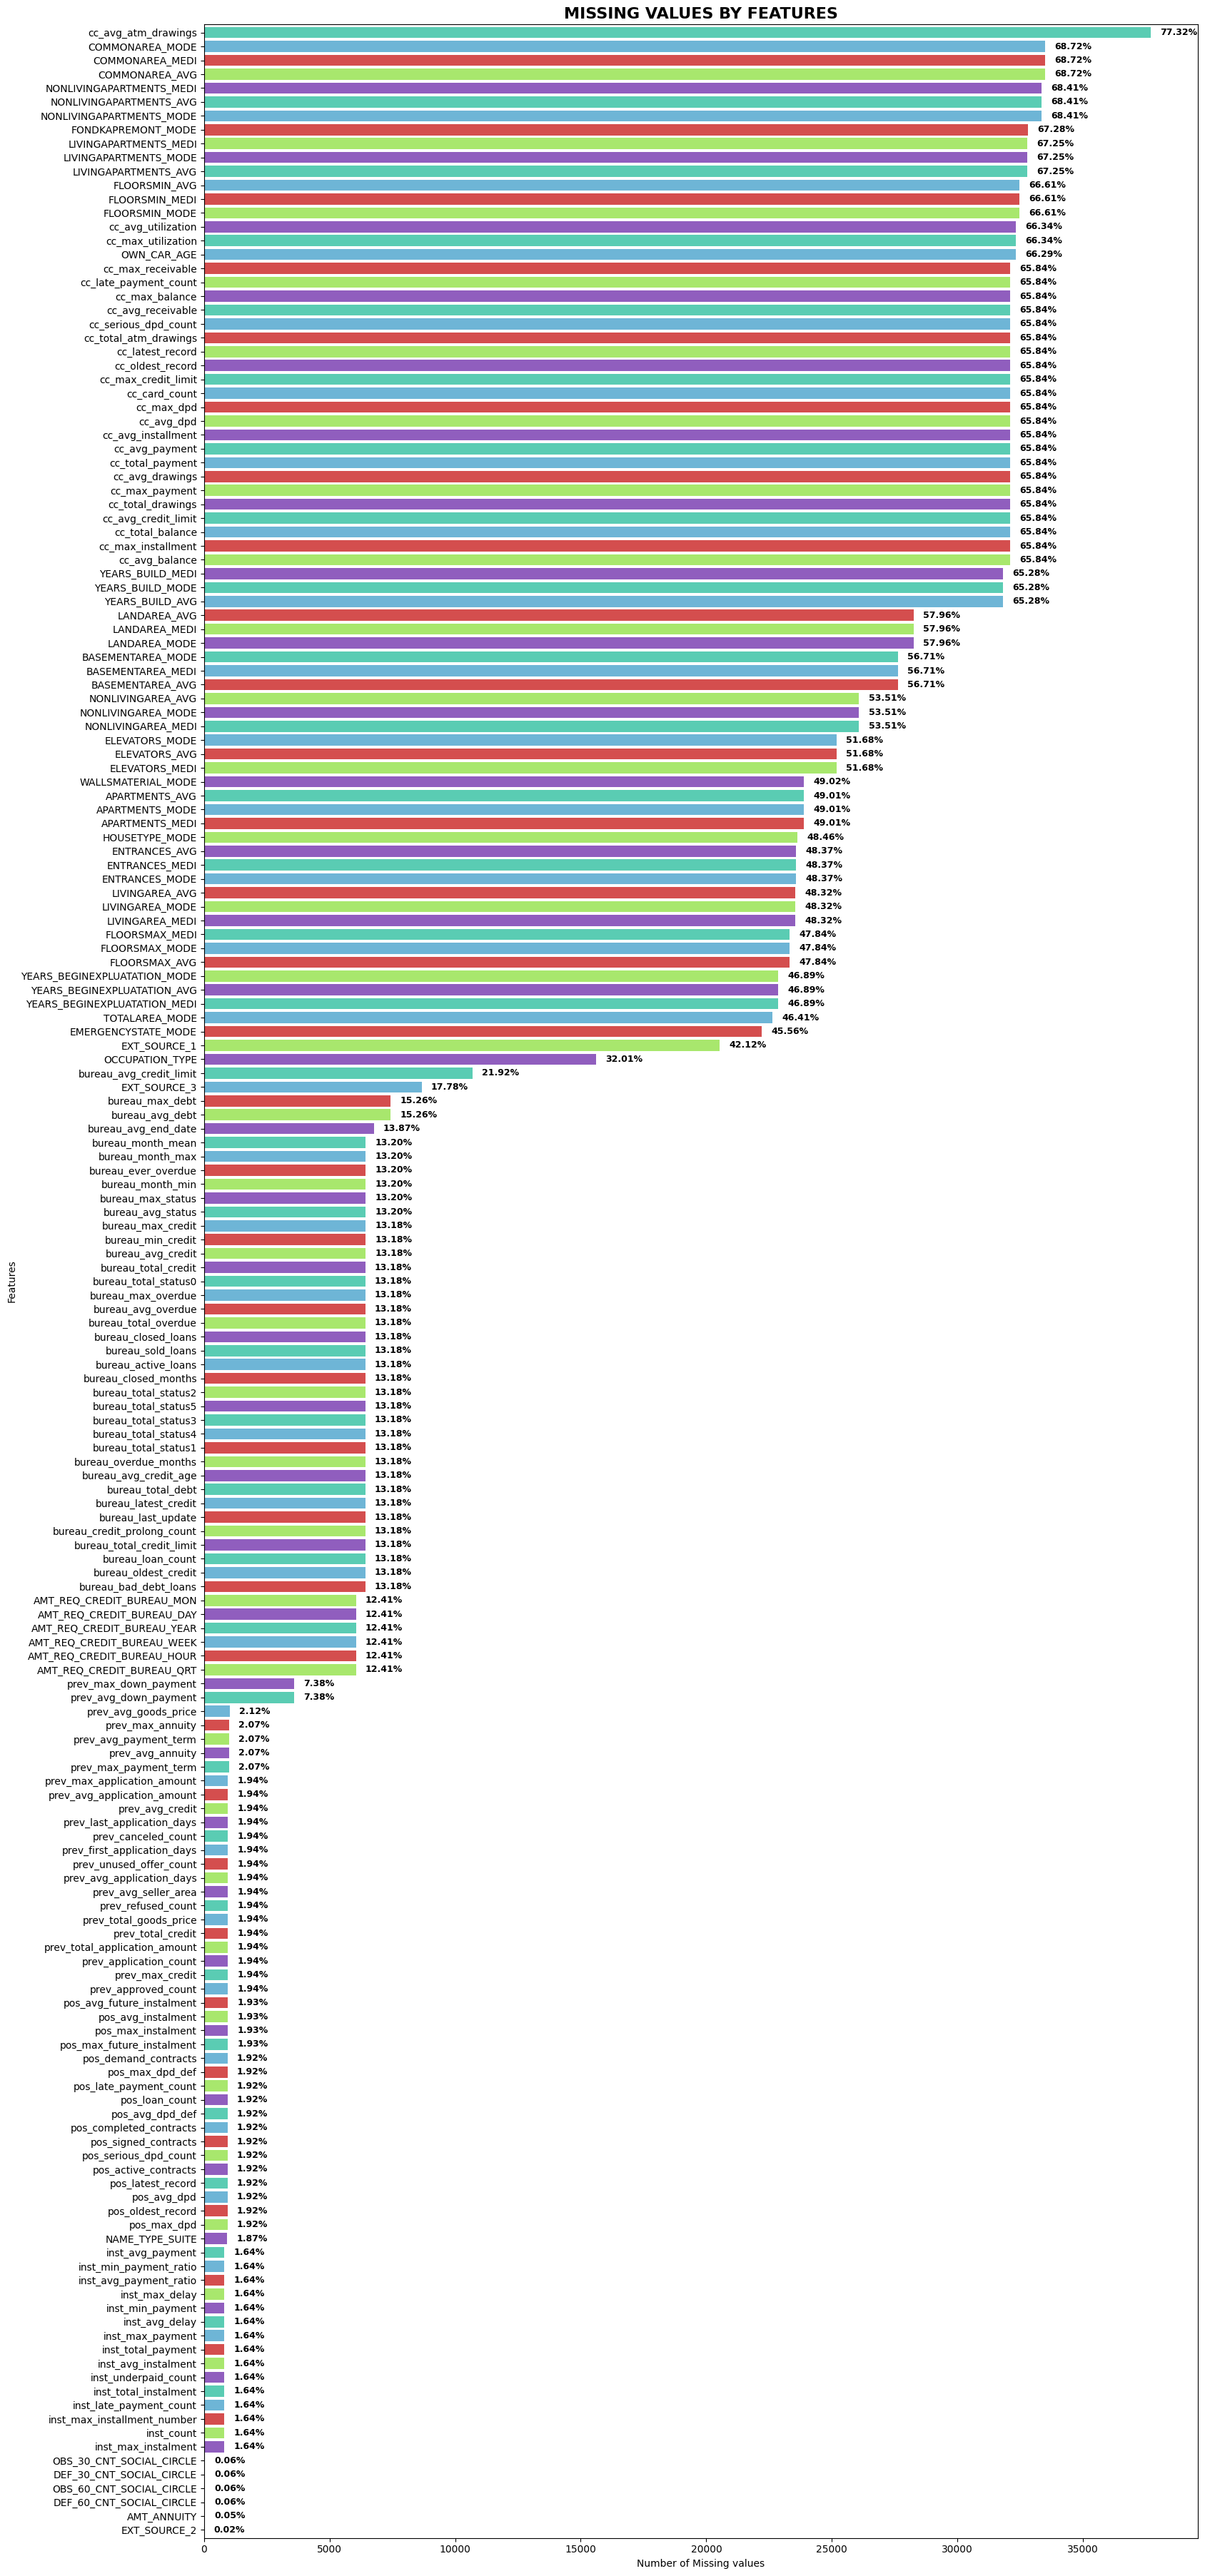

In [35]:
# Missing values in test dataset
Missing_value_plotter(
        test_df, 
        "Number of Missing values", 
        "Features",
        "MISSING VALUES BY FEATURES")

### **7. TARGET COLUMN DISTRIBUTION**

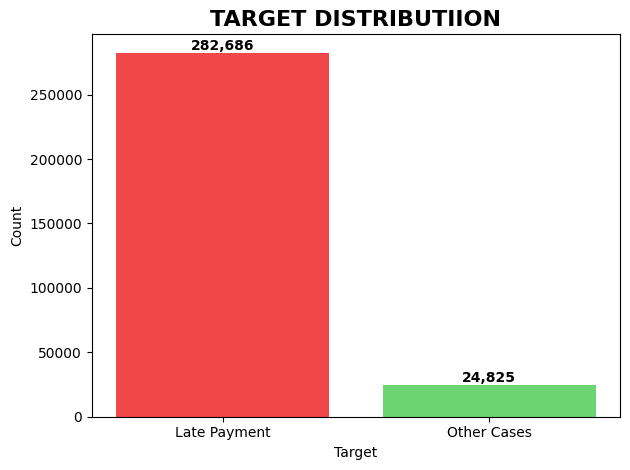

In [36]:
counts = train_df["TARGET"].value_counts().sort_index()
bars = plt.bar(counts.index.astype('str'), counts.values, color=["#F04848", "#6CD471"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha = "center",
        va = "bottom",
        fontsize = 10,
        fontweight = 'bold',

    )

plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0, 1], ["Late Payment", "Other Cases"])
plt.title("TARGET DISTRIBUTIION", fontsize= 16, fontweight = 'bold')
plt.tight_layout()
